In [1]:
import numpy as np                          
import pandas as pd                        
import matplotlib.pyplot as plt             
import seaborn as sns

In [2]:
data = {'Math': [90, 60, 75, 50],
        'Physics': [85, 55, 80, 45]}
df = pd.DataFrame(data, index=['Student A', 'Student B', 'Student C', 'Student D'])
print("Original Dataset:")
print(df)

Original Dataset:
           Math  Physics
Student A    90       85
Student B    60       55
Student C    75       80
Student D    50       45


In [4]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(X_scaled, columns=['Math_scaled', 'Physics_scaled'],
                          index=df.index)
df_scaled.head()

,Math_scaled,Physics_scaled
Student A,1.402136,1.121153
Student B,-0.577350,-0.672692
Student C,0.412393,0.822179
Student D,-1.237179,-1.270640


In [6]:
# n_components=2 means we keep 2 principal components
# Since we have 2 features, this is the maximum possible
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=df.index)
df_pca.head()

,PC1,PC2
Student A,1.784235,-0.198686
Student B,-0.883913,-0.067416
Student C,0.872974,0.289762
Student D,-1.773296,-0.023660


In [8]:
# This tells us HOW MUCH information each principal component holds
explained = pca.explained_variance_ratio_
print("Explained Variance Ratio:")
print(f"  PC1 explains: {explained[0]*100:.2f}% of total variance")
print(f"  PC2 explains: {explained[1]*100:.2f}% of total variance")

Explained Variance Ratio:
  PC1 explains: 98.39% of total variance
  PC2 explains: 1.61% of total variance


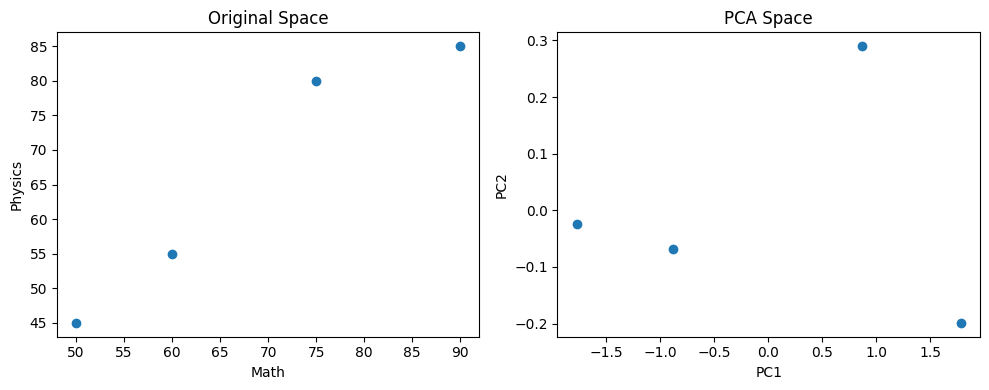

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Original data
ax[0].scatter(df["Math"], df["Physics"])
ax[0].set_title("Original Space")
ax[0].set_xlabel("Math")
ax[0].set_ylabel("Physics")

# PCA data
ax[1].scatter(X_pca[:, 0], X_pca[:, 1])
ax[1].set_title("PCA Space")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

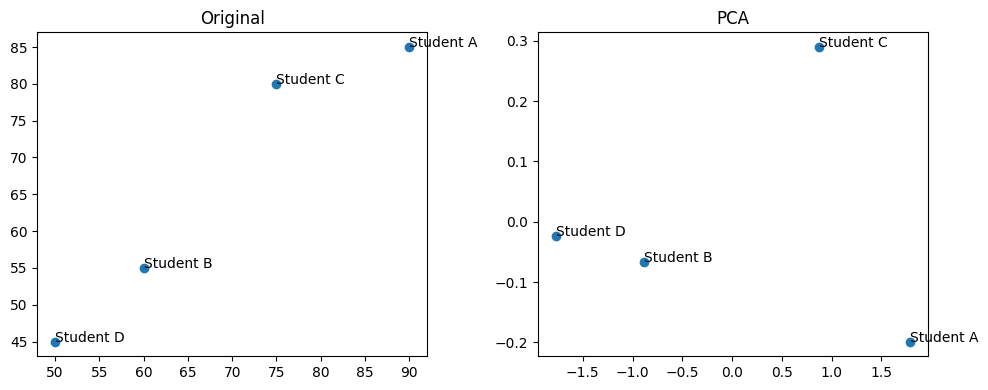

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Original
ax[0].scatter(df["Math"], df["Physics"])
for i, name in enumerate(df.index):
    ax[0].text(df.iloc[i]["Math"], df.iloc[i]["Physics"], name)

ax[0].set_title("Original")

# PCA 
ax[1].scatter(X_pca[:, 0], X_pca[:, 1])
for i, name in enumerate(df.index):
    ax[1].text(X_pca[i, 0], X_pca[i, 1], name)

ax[1].set_title("PCA")

plt.tight_layout()
plt.show()